In [2]:
import pandas as pd

import numpy as np
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

In [3]:
print(nav.columns)
print(performance.columns)
print(transactions.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [4]:
print(nav.head())

print(nav['amfi_code'].nunique())
print(nav.shape)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
40
(46000, 3)


In [5]:
nav.groupby('amfi_code').size().head()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
dtype: int64

In [6]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.columns)
holdings.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


Historical VaR & CVaR

In [7]:
import pandas as pd
import numpy as np

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

var_cvar = (
    nav.groupby('amfi_code')['daily_return']
    .apply(
        lambda x: pd.Series({
            'VaR_95': np.percentile(x.dropna(),5),
            'CVaR_95': x[x <= np.percentile(x.dropna(),5)].mean()
        })
    )
    .unstack()
    .reset_index()
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_cvar.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

Rolling 90-Day Sharpe

In [9]:
nav['rolling_sharpe'] = (
    nav.groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        x.rolling(90).mean() /
        x.rolling(90).std() *
        np.sqrt(252)
    )
)

In [10]:
top5 = (
    performance
    .sort_values('sharpe_ratio',ascending=False)
    .head(5)['amfi_code']
)

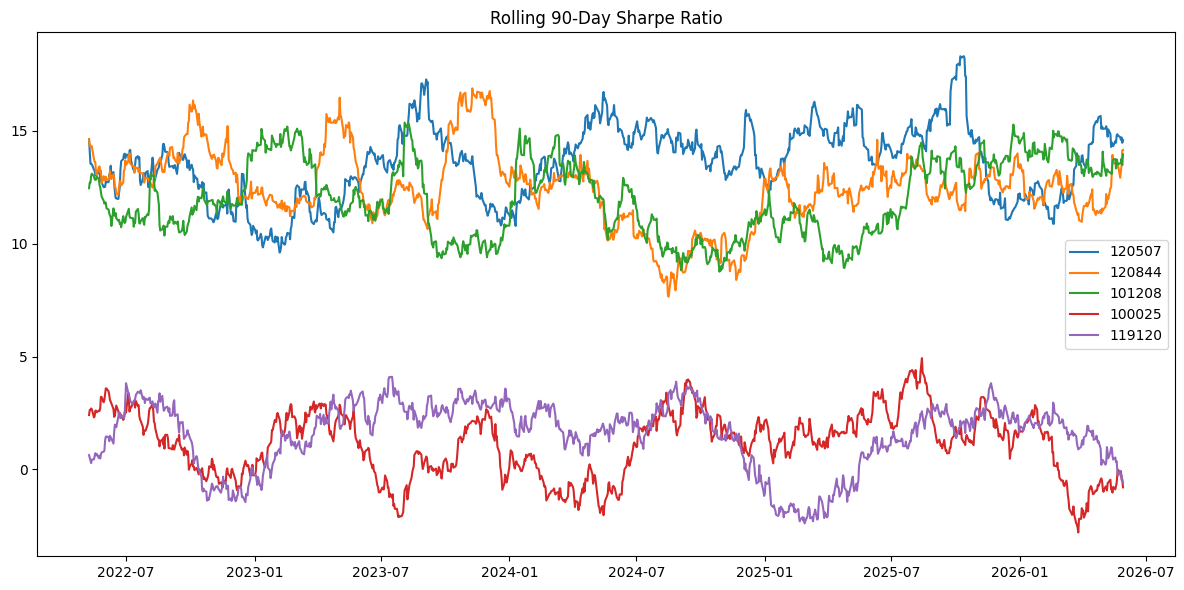

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav[nav['amfi_code']==fund]
    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [14]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['cohort_year'] = (
    transactions.groupby('investor_id')
    ['transaction_date']
    .transform('min')
    .dt.year
)

In [15]:
cohort_analysis = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum'),
        investors=('investor_id','nunique')
    )
    .reset_index()
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [16]:
top_fund_pref = (
    transactions
    .groupby(['cohort_year','amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund_pref = (
    top_fund_pref
    .sort_values(
        ['cohort_year','count'],
        ascending=[True,False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_fund_pref

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [17]:
sip_txns = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip_counts = (
    sip_txns.groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible_investors = sip_counts[
    sip_counts['sip_count'] >= 6
]['investor_id']

In [18]:
sip_txns = sip_txns[
    sip_txns['investor_id'].isin(eligible_investors)
]

sip_txns = sip_txns.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txns['gap_days'] = (
    sip_txns.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [19]:
sip_continuity = (
    sip_txns.groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

In [20]:
sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Healthy'
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [21]:
sip_continuity['status'].value_counts()

status
At-Risk    1332
Healthy      30
Name: count, dtype: int64

In [22]:
performance[['scheme_name','risk_grade','sharpe_ratio']].head()

,scheme_name,risk_grade,sharpe_ratio
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.88
1,SBI Bluechip Fund - Direct Plan - Growth,Moderate,0.81
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52


In [23]:
performance['risk_grade'].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [24]:
risk_appetite = "Moderate"
recommendations = (
    performance[
        performance['risk_grade'] == risk_appetite
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    [['scheme_name','risk_grade','sharpe_ratio']]
    .head(3)
)

recommendations

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [25]:
recommendations.to_csv(
    "../reports/fund_recommendations.csv",
    index=False
)

In [26]:
hhi = (
    holdings.groupby('amfi_code')['weight_pct']
    .apply(
        lambda x: ((x/100)**2).sum()
    )
    .reset_index(name='HHI')
)

hhi = hhi.sort_values(
    'HHI',
    ascending=False
)

hhi.head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


In [27]:
hhi.to_csv(
    "../reports/hhi_concentration.csv",
    index=False
)

In [28]:
import os

print(os.path.exists("../reports/var_cvar_report.csv"))
print(os.path.exists("../reports/rolling_sharpe_chart.png"))
print(os.path.exists("../reports/fund_recommendations.csv"))
print(os.path.exists("../reports/hhi_concentration.csv"))

True
True
True
True


# Advanced Insights

1. Historical VaR and CVaR analysis identified the schemes with the highest downside risk, helping distinguish aggressive funds from relatively stable options.

2. Rolling 90-Day Sharpe Ratios showed that a few funds consistently delivered superior risk-adjusted returns over time.

3. Investor cohort analysis revealed that newer investor cohorts contributed the largest total investments and maintained higher average SIP amounts.

4. SIP continuity analysis found that 1332 investors were classified as At-Risk due to average SIP gaps greater than 35 days, while only 30 investors maintained healthy continuity.

5. Portfolio concentration analysis using the Herfindahl-Hirschman Index (HHI) highlighted significant differences in diversification levels across funds, with some portfolios showing much higher concentration risk.